<a href="https://colab.research.google.com/github/hyui02/ESAA_assignment/blob/main/miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#0. 변수 정리
- title : 영화의 제목
- distributor : 배급사
- genre : 장르
- release_time : 개봉일
- time : 상영시간(분)
- screening_rat : 상영등급
- director : 감독이름
- dir_prev_bfnum : 해당 감독이 이 영화를 만들기 전 제작에 참여한 영화에서의 평균 관객수(단 관객수가 알려지지 않은 영화 제외)
- dir_prev_num : 해당 감독이 이 영화를 만들기 전 제작에 참여한 영화의 개수(단 관객수가 알려지지 않은 영화 제외)
- num_staff : 스텝수
- num_actor : 주연배우수
- box_off_num : **관객수**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

train = pd.read_csv('movies_train.csv')

In [35]:
#한글 폰트 깨짐 방지
!apt-get -qq -y install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False


#1. 데이터 확인 및 전처리

In [2]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    object 
 1   distributor     600 non-null    object 
 2   genre           600 non-null    object 
 3   release_time    600 non-null    object 
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    object 
 6   director        600 non-null    object 
 7   dir_prev_bfnum  270 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 56.4+ KB


- 문자열: 영화 제목, 배급사, 장르, 개봉일, 상용 등급, 감독 이름
- 정수: 상영시간, 해당 감독이 이 영화를 만들기 전 제작에 참여한 영화의 개수, 스텝수, 주연배우수, 관객수
- 실수: 해당 감독이 이 영화를 만들기 전 제작에 참여한 영화에서의 평균 관객수

In [3]:
train.isna().sum()

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,330
dir_prev_num,0
num_staff,0


In [4]:
#결측치의 발생원인: dir_prev_num(감독의 이전 작품) 이므로 신인 감독일 경우 결측치 발생-> 결측치의 경우, 그 자리에 0일 넣음
train['dir_prev_bfnum'] = train['dir_prev_bfnum'].fillna(0)
train.isna().sum()

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,0
dir_prev_num,0
num_staff,0


In [5]:
train.describe() #숫자열

,time,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
count,600.000000,6.000000e+02,600.000000,600.000000,600.000000,6.000000e+02
mean,100.863333,4.726993e+05,0.876667,151.118333,3.706667,7.081818e+05
std,18.097528,1.309474e+06,1.183409,165.654671,2.446889,1.828006e+06
min,45.000000,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
25%,89.000000,0.000000e+00,0.000000,17.000000,2.000000,1.297250e+03
50%,100.000000,0.000000e+00,0.000000,82.500000,3.000000,1.259100e+04
75%,114.000000,3.761416e+05,2.000000,264.000000,4.000000,4.798868e+05
max,180.000000,1.761531e+07,5.000000,869.000000,25.000000,1.426277e+07


=> 변수별 분석
  1. 상영시간: 극단적인 값 없이 고르게 분포된 안정적인 변수
  2. 감독의 이전 흥행 평균: 전체 영화의 절반 이상이 신인 감독 작품이고, 나머지 절반 정도만 실제 흥행 이력이 있다는 뜻. 이렇게 0이 많으니까 평균이 왜곡되기 쉬운 변수라는 것도 알 수 있어요.
  3. 감독의 이전 작품 수: 평균 0.88, 중앙값 0, 75%도 2에 불과해서 대부분 경력이 짧은 감독들 작품이라는 걸 보여줌
  4. 스태프 수: 평균과 중앙값이 어느 정도 차이가 있지만 극단적이진 않음 최댓값과 최솟값이 차이가 큰데, 75%가 264인 걸 보면 상위 25%에서 스태프 규모가 급격히 커지는 대형 제작 영화들이 있다는 뜻을 시사
  5. 주연배우 수:평균, 중앙값은 고르지만 최댓값 혼자 확 튐
  6. 관객 수: 평균과 중앙값이 차이가 큼 -> 로그를 사용하여 눌러줘야됨

In [6]:
train.describe(include=object)

,title,distributor,genre,release_time,screening_rat,director
count,600,600,600,600,600,600
unique,600,169,12,330,4,472
top,베를린,CJ 엔터테인먼트,드라마,2015-08-13,청소년 관람불가,홍상수
freq,1,54,221,6,204,7


1. 제목: unique가 600, freq가 1이라 전부 다 다른 값임.-> drop

2. 배급사: 169개 배급사 중 CJ 엔터테인먼트가 54번(9%)으로 가장 많아서, 소수 대형 배급사에 쏠려있고 대부분은 한두 편만 찍었음을 의미함.-> 상위 5개+기타로 묶는 처리가 필요해요.

3. 장르:12종류 중 드라마가 221번(37%)으로 압도적으로 많음

4. 개봉일자: 330개의 서로 다른 날짜에 600편이 개봉했고, 가장 많이 겹친 날짜(2015-08-13)에도 6편이나 몰려서 개봉했어요. 특정 시즌에 개봉일이 몰리는 경향이 있다는 뜻을 의미 -> 1) 년도별/ 2) 월별/ 3) 계절별 분류하는 전처리

5. 상영등급: 한 카테고리가 압도적으로 많지 않고 4개가 적당히 고르게 섞여 있다는 뜻, (전체/12세/15세/청불)

6. 감독: 472명 중 대부분이 영화를 1편씩만 찍어 카디널리티가 너무 높음 -> drop

분석한 내용을 토대로 간단한 전처리 진행

In [7]:
train = train.drop(columns=['title','director'])

In [9]:
train['release_time'] = pd.to_datetime(train['release_time'])
train['release_year'] = train['release_time'].dt.year
train['release_month'] = train['release_time'].dt.month

In [10]:
train['month'] = train['release_time'].dt.month
def func(month):
    if month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'fall'
    elif month in [12, 1, 2]:
        return 'winter'


train['season'] = train['month'].apply(lambda x: func(x))
train.head()

,distributor,genre,release_time,time,screening_rat,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num,release_year,release_month,month,season
0,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,0.00,0,91,2,23398,2012,11,11,fall
1,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,1161602.50,2,387,3,7072501,2015,11,11,fall
2,(주)쇼박스,액션,2013-06-05,123,15세 관람가,220775.25,4,343,4,6959083,2013,6,6,summer
3,(주)NEW,코미디,2012-07-12,101,전체 관람가,23894.00,2,20,6,217866,2012,7,7,summer
4,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,1.00,1,251,2,483387,2010,11,11,fall


In [24]:
distributor_list = train.distributor.value_counts()[:5]
def func(distributor):
    if distributor in distributor_list:
        return distributor
    else:
        return 'etc'

train['distributor'] = train['distributor'].apply(lambda x : func(x))

In [11]:
train['box_off_num_log'] = np.log1p(train['box_off_num'])

#3. 숫자형 그래프  

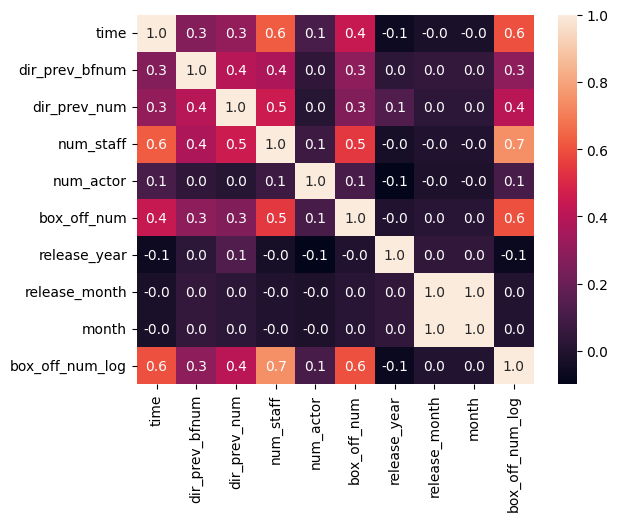

In [19]:
sns.heatmap(train.corr(numeric_only=True),fmt='.1f',annot=True)
plt.show()

- 관객수와 상관관계가 높은 변수: 스태프 수, 상영시간
- 이 두 변수로 산점도 확인
- release_month랑 month가 상관계수 1.0이므로 release_month drop

In [20]:
train=train.drop(columns=['release_month'])

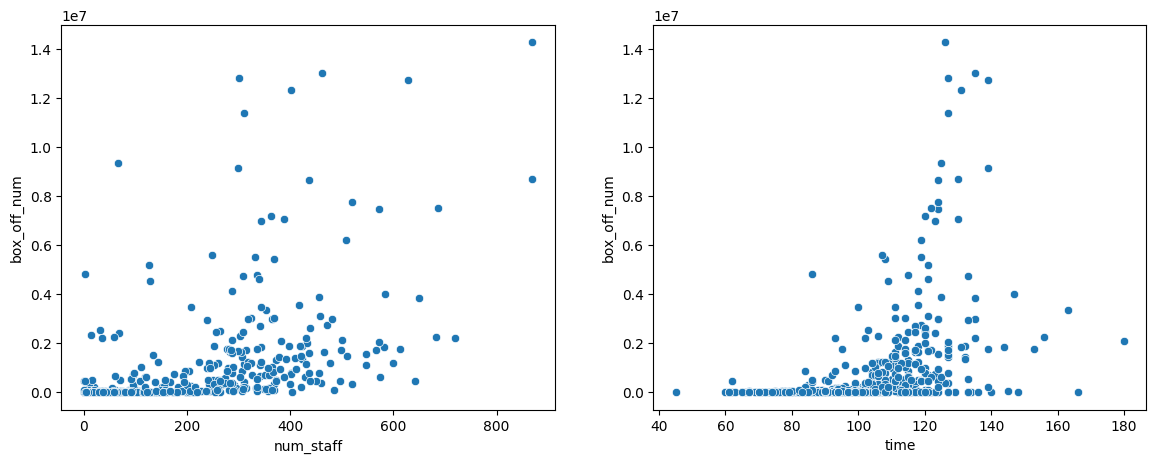

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='num_staff', y='box_off_num', data=train, ax=ax[0])
sns.scatterplot(x='time', y='box_off_num', data=train, ax=ax[1])

plt.show()

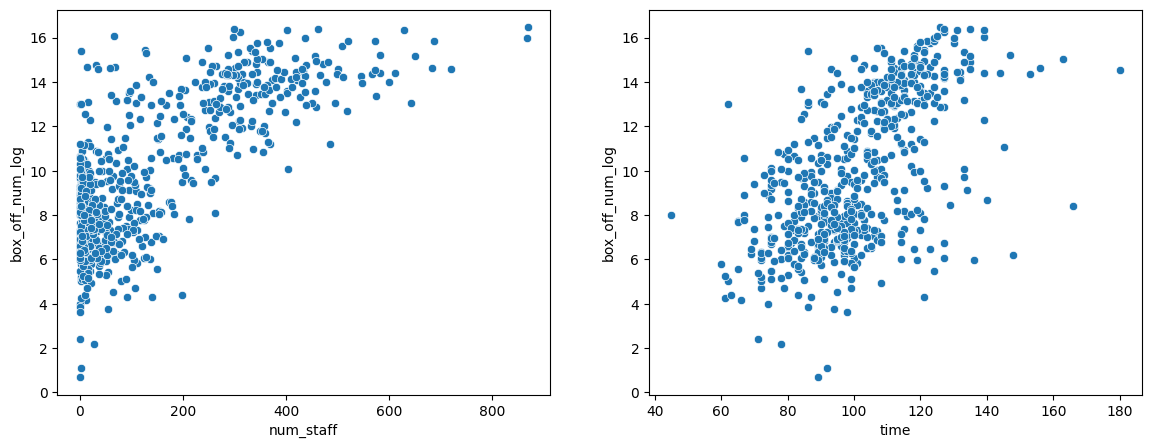

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(x='num_staff', y='box_off_num_log', data=train, ax=ax[0])
sns.scatterplot(x='time', y='box_off_num_log', data=train, ax=ax[1])

plt.show()

- 결과 분석

1.1 관객수 - 스태프 수 산점도
스태프 수 그래프를 보면, 스태프 수가 적을 땐(0~200 근처) 거의 다 낮은 관객수에 몰려있다가, 스태프 수가 늘어날수록(300 이상) 위쪽으로 튀는 점들이 조금씩 나타남. 즉 스태프가 많다고 무조건 잘 되는 건 아니지만, 스태프가 많아야 대박이 날 가능성이 생김. (확정은 x)

1.2 관객수 로그 - 스태프 수 산점도
스태프 수가 증가할 수록 우상향하는 경향
400명이 넘으면 기울기가 줄어듦

2.1 관객수 - 상영시간 산점도
가장 흥행한 영화들이 대부분 120-140분, 80분 이하 및 160분 이상은 관객수가 낮음.
-> 적정 시간대가 있다!

2.2 관객수 로그 - 상영시간  산점도
우상향 패턴, 120분 이상이 되면 큰 차이 없이 비슷한 수준
-> 상영시간이 길수록 무조건 좋은 건 아님. 120분 근처까지는 길수록 괜찮으나 그 이상은 효과 미미

#문자열 그래프

In [28]:
train.genre.value_counts()


,count
genre,
드라마,221
다큐멘터리,93
멜로/로맨스,78
코미디,53
공포,42
액션,28
느와르,27
애니메이션,21
미스터리,17


/tmp/ipykernel_20567/1759385209.py:4: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train,y='genre',x='box_off_num', palette=cubehelix, ci=None,ax=ax[0,0])
/tmp/ipykernel_20567/1759385209.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train,y='genre',x='box_off_num', palette=cubehelix, ci=None,ax=ax[0,0])
/tmp/ipykernel_20567/1759385209.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train,y='genre',x='box_off_num_log', palette=cubehelix, ci=None,ax=ax[0,1])
/tmp/ipykernel_20567/1759385209.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=

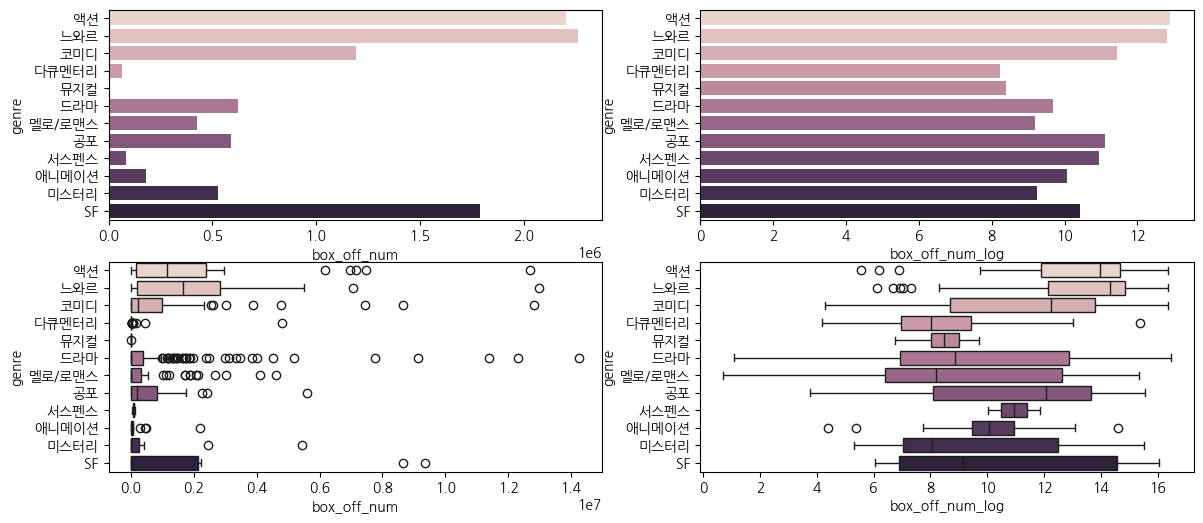

In [48]:
cubehelix = sns.cubehelix_palette(n_colors=train['genre'].nunique())
fig,ax=plt.subplots(2,2, figsize=(14,6))

sns.barplot(data=train,y='genre',x='box_off_num', palette=cubehelix, ci=None,ax=ax[0,0])
sns.barplot(data=train,y='genre',x='box_off_num_log', palette=cubehelix, ci=None,ax=ax[0,1])
sns.boxplot(data=train, y='genre', x='box_off_num',  palette=cubehelix,ax=ax[1,0])
sns.boxplot(data=train, y='genre', x='box_off_num_log',palette=cubehelix, ax=ax[1,1])


plt.show()

/tmp/ipykernel_20567/3723864923.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train,y='screening_rat',x='box_off_num', palette=mako,
/tmp/ipykernel_20567/3723864923.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train,y='screening_rat',x='box_off_num', palette=mako,
/tmp/ipykernel_20567/3723864923.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train,y='screening_rat',x='box_off_num_log', palette=mako,
/tmp/ipykernel_20567/3723864923.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train,y='screening_rat',x='box_off_num_log', palett

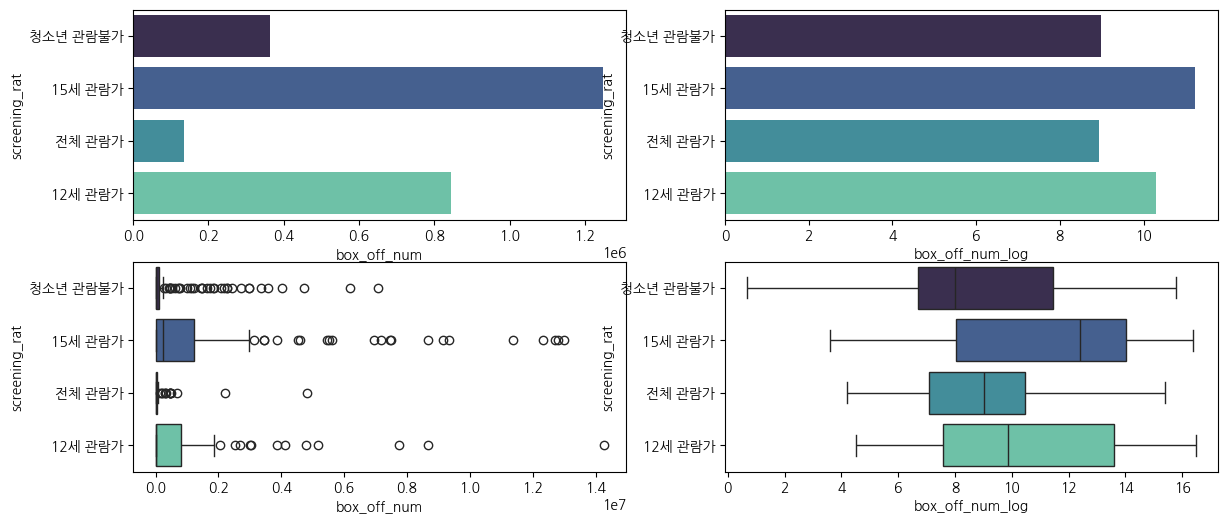

In [49]:
mako = sns.color_palette("mako", n_colors=train['screening_rat'].nunique())

fig,ax=plt.subplots(2,2, figsize=(14,6))

sns.barplot(data=train,y='screening_rat',x='box_off_num', palette=mako,
            ci=None,ax=ax[0,0])
sns.barplot(data=train,y='screening_rat',x='box_off_num_log', palette=mako,
            ci=None,ax=ax[0,1])
sns.boxplot(data=train, y='screening_rat', x='box_off_num',
            palette=mako, ax=ax[1,0])
sns.boxplot(data=train, y='screening_rat', x='box_off_num_log', palette=mako,
            ax=ax[1,1])

plt.show()

/tmp/ipykernel_20567/2846636510.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train,y='season',x='box_off_num', palette=magma,
/tmp/ipykernel_20567/2846636510.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train,y='season',x='box_off_num', palette=magma,
/tmp/ipykernel_20567/2846636510.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train,y='season',x='box_off_num_log', palette=magma,
/tmp/ipykernel_20567/2846636510.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train,y='season',x='box_off_num_log', palette=magma,
/tmp/ipykernel_2

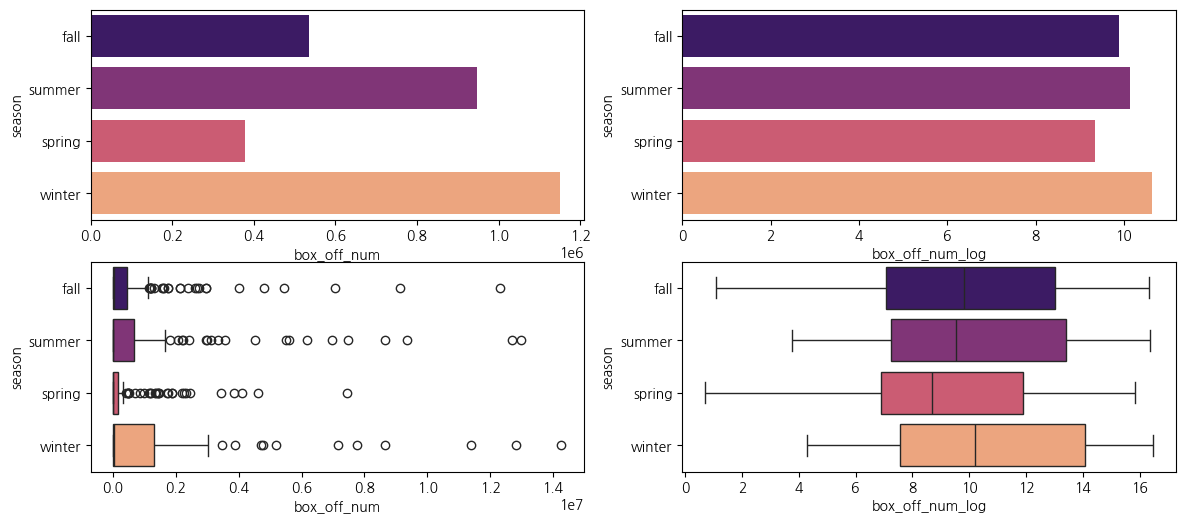

In [50]:
magma = sns.color_palette("magma", n_colors=train['season'].nunique())

fig,ax=plt.subplots(2,2, figsize=(14,6))

sns.barplot(data=train,y='season',x='box_off_num', palette=magma,
            ci=None,ax=ax[0,0])
sns.barplot(data=train,y='season',x='box_off_num_log', palette=magma,
            ci=None,ax=ax[0,1])
sns.boxplot(data=train, y='season', x='box_off_num',
            palette=magma, ax=ax[1,0])
sns.boxplot(data=train, y='season', x='box_off_num_log', palette=magma,
            ax=ax[1,1])

plt.show()

/tmp/ipykernel_20567/261636734.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train,y='distributor',x='box_off_num', palette=icefire,
/tmp/ipykernel_20567/261636734.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train,y='distributor',x='box_off_num', palette=icefire,
/tmp/ipykernel_20567/261636734.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=train,y='distributor',x='box_off_num_log', palette=icefire,
/tmp/ipykernel_20567/261636734.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=train,y='distributor',x='box_off_num_log', palette=i

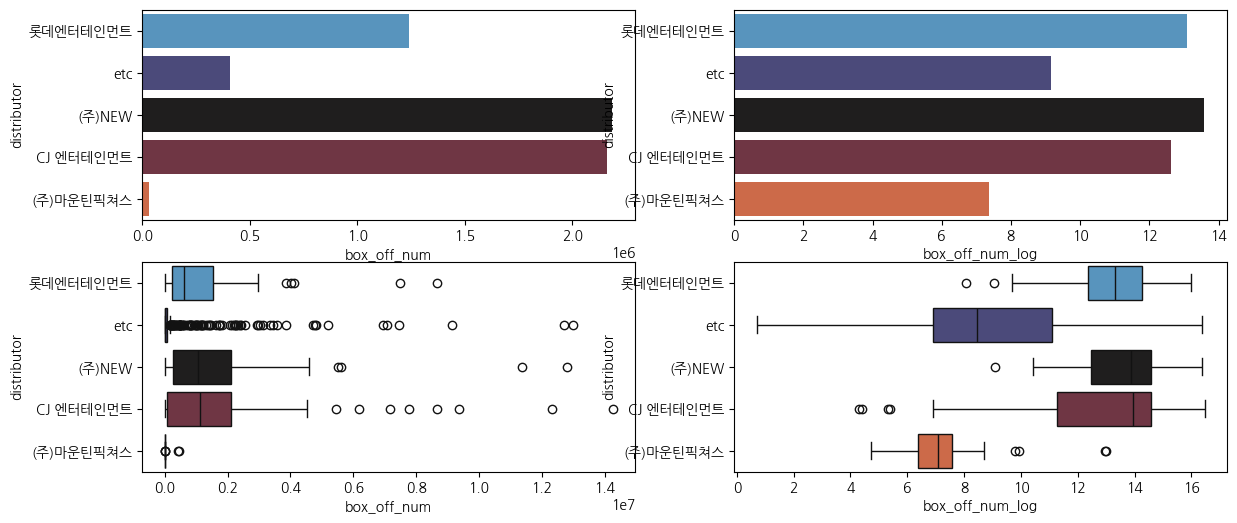

In [51]:
icefire = sns.color_palette("icefire", n_colors=train['distributor'].nunique())

fig,ax=plt.subplots(2,2, figsize=(14,6))

sns.barplot(data=train,y='distributor',x='box_off_num', palette=icefire,
            ci=None,ax=ax[0,0])
sns.barplot(data=train,y='distributor',x='box_off_num_log', palette=icefire,
            ci=None,ax=ax[0,1])
sns.boxplot(data=train, y='distributor', x='box_off_num',
            palette=icefire, ax=ax[1,0])
sns.boxplot(data=train, y='distributor', x='box_off_num_log', palette=icefire,
            ax=ax[1,1])

plt.show()